# QDock-Kaiwu — docking pose sampling on the Kaiwu SDK

Molecular docking splits into **pose sampling** (NP-hard) and **scoring**.
QDock encodes pose sampling as a **QUBO**; we solve it on Kaiwu — the classical
**simulated-annealing** optimizer and the real **Coherent Ising Machine** — and
score the poses with **AutoDock Vina**.

Outline: QUBO basics → solve on Kaiwu **SA** and **CIM** → **GPM** and **FAM**
redocking of 1y6r with Vina → grid-resolution study. Each step has a plot.

## 0. Setup

In [1]:
import os, sys, itertools, numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
os.environ['PATH'] = os.path.expanduser('~/miniforge3/envs/chem/bin') + os.pathsep + os.environ['PATH']
sys.path.insert(0, os.path.abspath('..'))
import kaiwu as kw
from qdock_kaiwu import GPMDock, FAMDock, scoring, evaluate, backends, params, viz, init_license

# License: set KAIWU_USER_ID / KAIWU_SDK_CODE in your environment, then:
init_license()
# ...or pass them directly:  init_license(user_id='YOUR_ID', sdk_code='YOUR_CODE')
DATA = os.path.abspath('../data')

## 1. A QUBO, solved on Kaiwu SA and CIM

Kaiwu minimizes an **Ising** Hamiltonian and returns **spin** (±1) solutions.
We convert QUBO↔Ising with Kaiwu's routine and map the ancilla-gauged spins
back to binary `x = (1 + s·s_anc)/2`. Here is a 4-variable QUBO — its matrix
carries the rewards on the diagonal and the couplings off-diagonal.

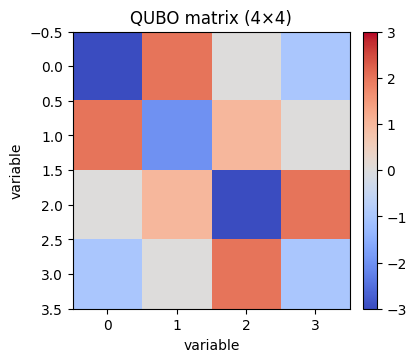

brute-force minimum : -6.0


In [2]:
Q = np.array([[-3.,  2.,  0., -1.],
              [ 0., -2.,  1.,  0.],
              [ 0.,  0., -3.,  2.],
              [ 0.,  0.,  0., -1.]])
fig, ax = plt.subplots(figsize=(4.2, 3.6)); viz.plot_qubo_matrix(ax, Q); plt.show()
brute = min(backends.qubo_energy(Q, np.array(b)) for b in itertools.product([0,1], repeat=4))
print('brute-force minimum :', brute)

### Solve with the **SA** optimizer (`kaiwu.classical.SimulatedAnnealingOptimizer`)

We feed the converter's output **straight to `solve` — no manual sign flip**.
(Kaiwu's raw `solve` maximizes sᵀMs, but `qubo_matrix_to_ising_matrix` already
encodes the sign, so this minimizes the QUBO.)

In [3]:
ising, offset = kw.conversion.qubo_matrix_to_ising_matrix(Q)
sa = kw.classical.SimulatedAnnealingOptimizer(initial_temperature=5, alpha=0.99,
         cutoff_temperature=0.01, iterations_per_t=200, size_limit=50, rand_seed=42)
spins = sa.solve(ising)
ranked = backends._rank_unique([backends._spins_to_binary(s, 4) for s in spins], Q)
print('SA best energy     :', ranked[0][0], ' solution:', ranked[0][1])
print('matches brute force:', abs(ranked[0][0]-brute) < 1e-9)

SA best energy     : -6.0  solution: [1 0 1 1]
matches brute force: True


### Solve the same QUBO on the real **CIM** (`kaiwu.cim.CIMOptimizer`)

This submits the Ising matrix to the photonic machine and polls the result
(~1 minute, uses quota). The CIM suits small QUBOs like this one.

In [4]:
kw.common.CheckpointManager.save_dir = '/tmp/kaiwu_cim'; os.makedirs('/tmp/kaiwu_cim', exist_ok=True)
cim = kw.cim.CIMOptimizer(task_name='qdock_workshop_demo', wait=True,
                          interval=1, task_mode='quota', sample_number=10)
spins_cim = np.asarray(cim.solve(ising))
ranked_cim = backends._rank_unique([backends._spins_to_binary(s, 4) for s in spins_cim], Q)
print('CIM best energy    :', ranked_cim[0][0], ' solution:', ranked_cim[0][1])
print('matches brute force:', abs(ranked_cim[0][0]-brute) < 1e-9)

[2026-06-22 13:48:32] [INFO    ] [kaiwu.cim._optimizer_adapter:4] - Task calculation successful!, Task name: qdock_workshop_demo


CIM best energy    : -6.0  solution: [1 0 1 0]
matches brute force: True


## 2. Grid Point Matching — redock 1y6r

Fill the pocket with a 2.0 Å grid; AutoGrid gives each point a van der Waals
energy (the QUBO reward). One variable per (ligand atom, grid point).

In [5]:
g = GPMDock(backend='sa', workdir='nb_gpm')      # backend='cim' for the machine
g.make_receptor(f'{DATA}/1y6r_protein.pdb')
g.make_ligand([f'{DATA}/1y6r_ligand.mol2'])
g.make_box_ligand(f'{DATA}/1y6r_ligand.mol2')    # grid 2.0 Å (GPM default)
lig = g.ligands[0]

**The docking box** — favourable grid points (blue) around the ligand (black):

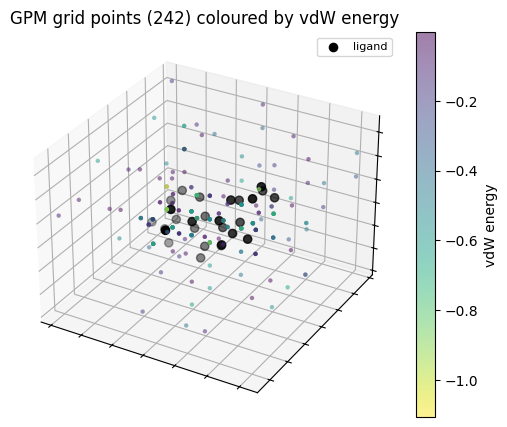

favourable grid points shown: 242


In [6]:
gpts = np.vstack([g.box_coords[g.grid_dict[t][0]] for t in g.grid_dict if len(g.grid_dict[t][0])])
gen  = np.concatenate([g.grid_dict[t][1] for t in g.grid_dict if len(g.grid_dict[t][0])])
fig = plt.figure(figsize=(6, 5)); ax = fig.add_subplot(111, projection='3d')
viz.plot_grid_sites(ax, gpts, gen, lig.coords); plt.show()
print(f'favourable grid points shown: {len(gpts)}')

**Sample poses** and judge them against the crystal structure:

QUBO variables (qubits): 1128   reads (poses): 300
mRMSD: 0.15 Å   (<2.0 Å: True,  <1.5 Å: True)


/Users/songxinwei/Downloads/qdock-kaiwu-workshop/qdock_kaiwu/viz.py:128: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


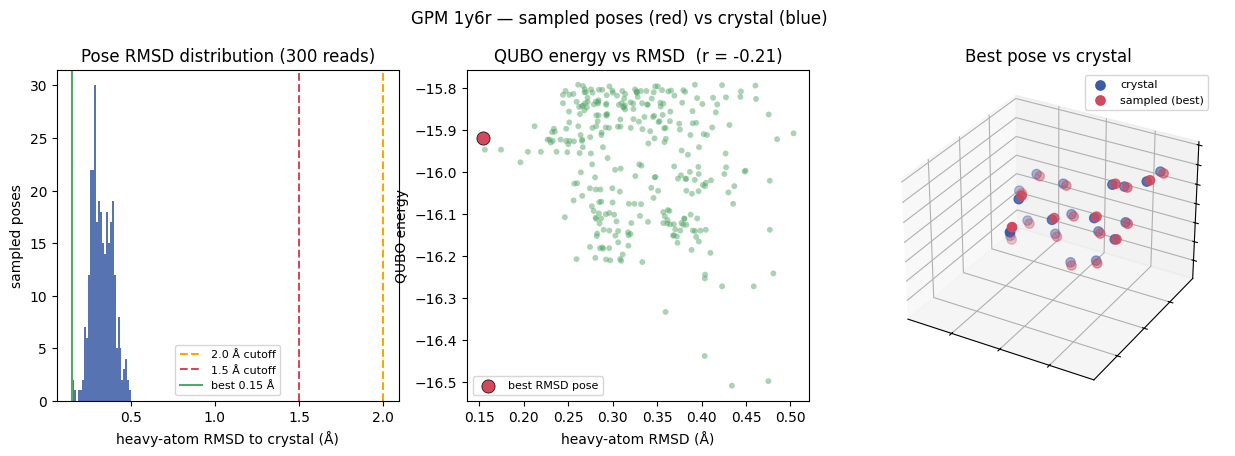

In [7]:
poses = g.dock(lig)
r = evaluate.pose_rmsds(poses, lig.coords, lig.elements); best = int(r.argmin())
print(f'QUBO variables (qubits): {g.last_qubo.shape[0]}   reads (poses): {len(poses)}')
print(f'mRMSD: {r.min():.2f} Å   (<2.0 Å: {r.min()<2.0},  <1.5 Å: {r.min()<1.5})')
fig = viz.summary_figure(r, g.last_energies, poses[best], lig.coords, lig.elements,
                         suptitle='GPM 1y6r — sampled poses (red) vs crystal (blue)')
plt.show()

The middle panel is the key check: **lower QUBO energy tracks lower RMSD**, so
minimizing the Ising Hamiltonian really does drive toward the native pose.
Now score the poses with AutoDock Vina:

In [8]:
vb = scoring.score_pose(g.receptor_pdbqt, lig.lines, poses[best], 'nb_gpm/score', 'best')
vc = scoring.score_pose(g.receptor_pdbqt, lig.lines, lig.coords,   'nb_gpm/score', 'cryst')
print(f'Vina, best-RMSD pose : {vb:.2f} kcal/mol')
print(f'Vina, crystal pose   : {vc:.2f} kcal/mol')

Vina, best-RMSD pose : -11.35 kcal/mol
Vina, crystal pose   : -11.80 kcal/mol


## 3. Feature Atom Matching — a fixed, pocket-based encoding

FAM replaces the dense energy grid with a small, **fixed** set of pocket
feature atoms. Its qubit count (atoms × features) does not grow as you refine
the grid or enlarge the box, which is why FAM scales to large targets where
GPM's grid explodes (paper: 3 640 vs 13 908 qubits on the largest CASF case).
For this small ligand in a coarse 2.0 Å grid the two are comparable. Same
target, for a direct comparison.

In [9]:
f = FAMDock(backend='sa', workdir='nb_fam')
f.make_receptor(f'{DATA}/1y6r_protein.pdb')
f.make_ligand([f'{DATA}/1y6r_ligand.mol2'])
f.make_box_ligand(f'{DATA}/1y6r_ligand.mol2')    # 1.0 Å (FAM default)
ligf = f.ligands[0]

**The feature atoms** — a handful of typed pocket points (vs hundreds of grid points):

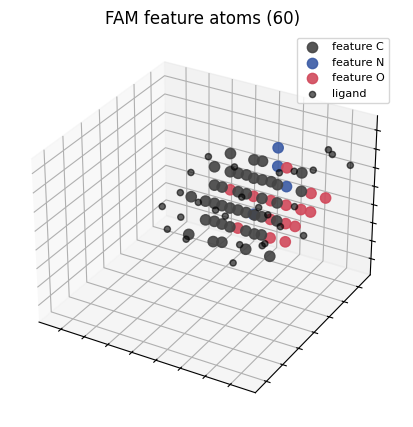

feature atoms: 60


In [10]:
fig = plt.figure(figsize=(6, 5)); ax = fig.add_subplot(111, projection='3d')
viz.plot_feature_sites(ax, f.feat_coords, f.feat_elements, ligf.coords); plt.show()
print(f'feature atoms: {len(f.feat_coords)}')

**Sample poses** with FAM:

FAM mRMSD = 1.46 Å  (<2.0 Å: True,  <1.5 Å: True)


/Users/songxinwei/Downloads/qdock-kaiwu-workshop/qdock_kaiwu/viz.py:128: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


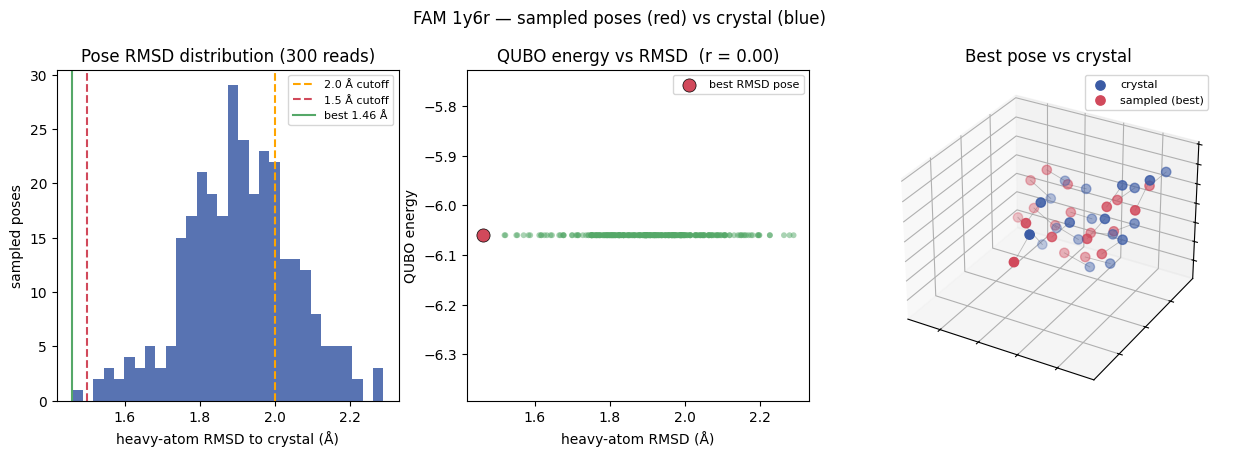


Same target:  GPM 0.15 Å @ 1128 qubits  vs  FAM 1.46 Å @ 1620 qubits (60 features)


In [11]:
posesf = f.dock(ligf)
rf = evaluate.pose_rmsds(posesf, ligf.coords, ligf.elements); bf = int(rf.argmin())
print(f'FAM mRMSD = {rf.min():.2f} Å  (<2.0 Å: {rf.min()<2.0},  <1.5 Å: {rf.min()<1.5})')
fig = viz.summary_figure(rf, f.last_energies, posesf[bf], ligf.coords, ligf.elements,
                         suptitle='FAM 1y6r — sampled poses (red) vs crystal (blue)')
plt.show()
print(f'\nSame target:  GPM {r.min():.2f} Å @ {g.last_qubo.shape[0]} qubits  vs  '
      f'FAM {rf.min():.2f} Å @ {f.last_qubo.shape[0]} qubits ({len(f.feat_coords)} features)')

## 4. Grid resolution — each encoding on its own scale

A ligand atom cannot match closer than the nearest site, so grid spacing sets
a floor on accuracy (the *discretization error*). Each encoding is refined on
its own scale: **GPM 2.0 → 1.5 Å** and **FAM 1.0 → 0.5 Å**.

GPM grid 2.0 Å : discretization_error=0.98 Å  mRMSD=0.15 Å


GPM grid 1.5 Å : discretization_error=0.72 Å  mRMSD=2.41 Å
FAM spacing 1.0 Å : discretization_error=0.43 Å


FAM spacing 0.5 Å : discretization_error=0.23 Å


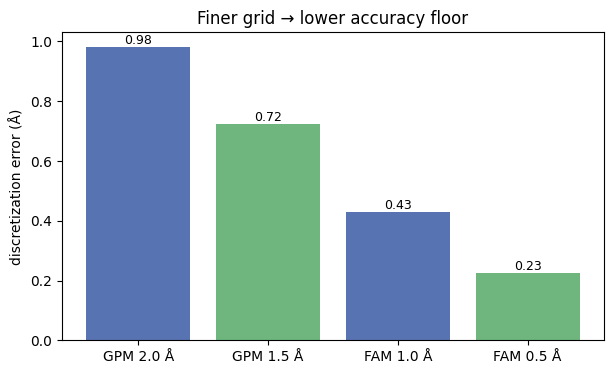

In [12]:
def gpm_disc(gl):
    gg = GPMDock(backend='sa', workdir=f'nb_gpm_{gl}')
    gg.make_receptor(f'{DATA}/1y6r_protein.pdb'); gg.make_ligand([f'{DATA}/1y6r_ligand.mol2'])
    gg.make_box_ligand(f'{DATA}/1y6r_ligand.mol2', grid_length=gl)
    L = gg.ligands[0]; P = gg.dock(L, save_pose=False)
    rr = evaluate.pose_rmsds(P, L.coords, L.elements)
    return evaluate.discretization_error(L.coords, gg.box_coords, L.elements), float(rr.min())

labels, discs = [], []
for gl in (params.GPM['grid_length'], params.GPM['grid_length_fine']):
    de, m = gpm_disc(gl)
    labels.append(f'GPM {gl} Å'); discs.append(de)
    print(f'GPM grid {gl} Å : discretization_error={de:.2f} Å  mRMSD={m:.2f} Å')
for gl in (params.FAM['grid_length'], params.FAM['grid_length_fine']):
    de = evaluate.discretization_error(ligf.coords, f.feature_coords_at(gl), ligf.elements)
    labels.append(f'FAM {gl} Å'); discs.append(de)
    print(f'FAM spacing {gl} Å : discretization_error={de:.2f} Å')
fig, ax = plt.subplots(figsize=(7, 4)); viz.plot_resolution_bars(ax, labels, discs); plt.show()

Finer grids lower the discretization floor (geometric). Realizing it as a
lower mRMSD needs a solver budget — reads, iterations, or a larger machine —
that keeps pace with the finer grid's larger QUBO.

## 5. Where QDock stands

Published sampling power (CASF-2016, 257 cases, success = mRMSD < 2 Å):

| method | success @ 2 Å | avg. mRMSD |
|---|---|---|
| Glide SP | 93.4 % | 1.0 Å |
| **GPM** | 87.5 % | 1.1 Å |
| **FAM** | 67.3 % | 1.8 Å |

**Takeaways**
- Pose sampling → **QUBO** → solved on Kaiwu **SA** (CPU) or the real **CIM**.
- Feed `qubo_matrix_to_ising_matrix(Q)` straight to `solve` — no manual sign flip.
- **GPM** is accurate (≈ Glide SP); **FAM** trades accuracy for far fewer qubits.
- The SA initial temperature must match the QUBO energy scale (T₀ ≈ 10 here).
- Accuracy is set by grid resolution, refined per encoding.